# SPAM EMAIL CLASSIFIER — النسخة المحسّنة
**التغييرات الرئيسية موثّقة بتعليق `# [FIX]` أو `# [IMPROVE]`**

## 1. IMPORTS

In [3]:
# [FIX] جمع جميع الاستيرادات في خلية واحدة بدلاً من توزيعها
# [FIX] حذف LinearRegression غير المستخدم
import re
import joblib
import numpy as np
import pandas as pd
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report,accuracy_score
from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier

# [IMPROVE] تحديد المسار كمتغير ثابت بدلاً من مسار صعب مضمّن
DATA_PATH = "spam_email_dataset.csv"  # عدّله حسب مسار ملفك

## 2. EDA — التحليل الاستكشافي

In [4]:
data = pd.read_csv(DATA_PATH)
print(f"حجم الداتا: {data.shape}")
data.head()

حجم الداتا: (10000, 20)


,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [5]:
print(f"عدد الصفوف المكررة: {data.duplicated().sum()}")
print(f"القيم المفقودة:\n{data.isna().sum()}")
print(f"\nتوزيع التصنيفات:\n{data['label'].value_counts()}")

عدد الصفوف المكررة: 0
القيم المفقودة:
email_id                   0
subject                    0
email_text                 0
num_words                  0
num_characters             0
num_exclamation_marks      0
num_links                  0
has_suspicious_link        0
num_attachments            0
has_attachment             0
sender_email               0
sender_domain              0
sender_reputation_score    0
email_hour                 0
email_day_of_week          0
is_weekend                 0
num_recipients             0
contains_money_terms       0
contains_urgency_terms     0
label                      0
dtype: int64

توزيع التصنيفات:
label
0    6005
1    3995
Name: count, dtype: int64


معامل الارتباط:
                num_words  num_characters
num_words        1.000000        0.969111
num_characters   0.969111        1.000000


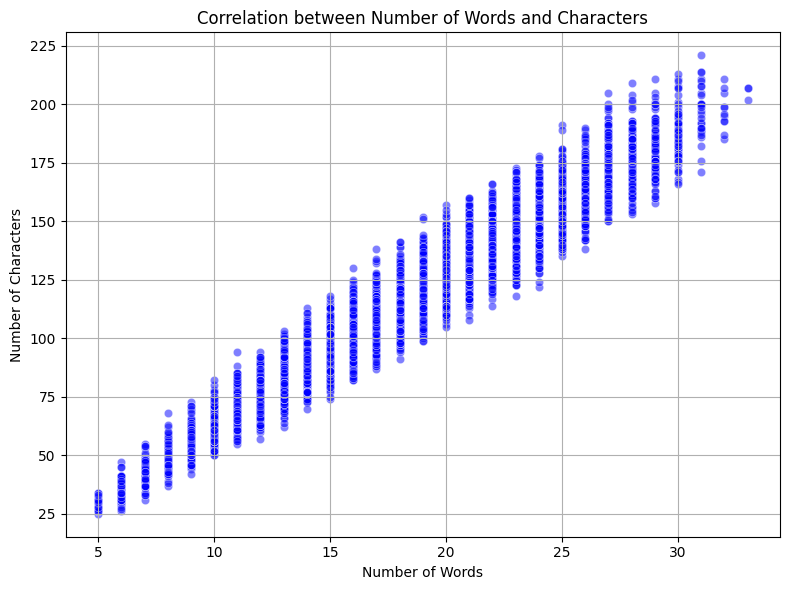

In [6]:
# تحليل الارتباط بين num_words و num_characters
correlation = data[['num_words', 'num_characters']].corr()
print(f"معامل الارتباط:\n{correlation}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='num_words', y='num_characters', data=data, color='blue', alpha=0.5)
plt.title('Correlation between Number of Words and Characters')
plt.xlabel('Number of Words')
plt.ylabel('Number of Characters')
plt.grid(True)
plt.tight_layout()
plt.show()

# [NOTE] الارتباط قوي جداً (0.97) → حذف num_characters صحيح لتجنب التكرار

## 3. TEXT PREPROCESSING — معالجة النصوص

In [7]:
# [FIX] حذف الأعمدة غير المفيدة مع توثيق سبب كل حذف
# - email_id: مجرد رقم تسلسلي لا قيمة تنبؤية له
# - sender_email: سيُعالج بشكل منفصل لاحقاً (Domain مستخرج منه بالفعل)
# - has_attachment: redundant مع num_attachments
# - num_characters: ارتباط 0.97 مع num_words → تكرار
# - num_exclamation_marks: std=0 (جميع القيم = صفر) → عمود ميت
data.drop(
    columns=["email_id", "sender_email", "has_attachment",
             "num_characters", "num_exclamation_marks"],
    inplace=True
)
print("الأعمدة المتبقية:", data.columns.tolist())

الأعمدة المتبقية: ['subject', 'email_text', 'num_words', 'num_links', 'has_suspicious_link', 'num_attachments', 'sender_domain', 'sender_reputation_score', 'email_hour', 'email_day_of_week', 'is_weekend', 'num_recipients', 'contains_money_terms', 'contains_urgency_terms', 'label']


In [8]:
# تحميل موارد NLTK (مرة واحدة فقط)
for pkg in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger_eng', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [9]:
# دمج العنوان مع نص البريد
data['full_text'] = data['subject'].fillna('') + " " + data['email_text'].fillna('')
print(data[['subject', 'email_text', 'full_text']].head())

            subject                                         email_text  \
0     Weekly Report  budget review - Statement our I claim world st...   
1    Project Update  team sync - President series today already. In...   
2    🔥WIN BIG NOW!!  win free urgent offer limited limited urgent u...   
3    🔥WIN BIG NOW!!  guarantee click now cash offer click now guara...   
4  Meeting Reminder  team sync - Significant property hotel not add...   

                                           full_text  
0  Weekly Report budget review - Statement our I ...  
1  Project Update team sync - President series to...  
2  🔥WIN BIG NOW!! win free urgent offer limited l...  
3  🔥WIN BIG NOW!! guarantee click now cash offer ...  
4  Meeting Reminder team sync - Significant prope...  


In [10]:
def get_wordnet_pos(treebank_tag: str) -> str:
    """تحويل تصنيف NLTK إلى تصنيف WordNet لـ Lemmatization أدق."""
    mapping = {'J': wordnet.ADJ, 'V': wordnet.VERB,
               'N': wordnet.NOUN, 'R': wordnet.ADV}
    return mapping.get(treebank_tag[0], wordnet.NOUN)


def preprocess_text(text: str) -> str:
    """تنظيف وتطبيع النص مع Lemmatization مُحسَّن."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)   # حذف علامات الترقيم
    text = re.sub(r'\d+', ' ', text)        # [IMPROVE] حذف الأرقام — لا قيمة لغوية
    words = text.split()

    # POS Tagging + Lemmatization (نهج دقيق)
    pos_tags = nltk.pos_tag(words)
    return ' '.join(
        lemmatizer.lemmatize(word, pos=get_wordnet_pos(tag))
        for word, tag in pos_tags
        if word not in stop_words and len(word) > 1  # [IMPROVE] تجاهل الكلمات أحرف واحد
    )

In [11]:
print("جاري معالجة النصوص... (قد يستغرق بضع دقائق)")
data['clean_text'] = data['full_text'].apply(preprocess_text)
print(data[['full_text', 'clean_text']].head())

جاري معالجة النصوص... (قد يستغرق بضع دقائق)
                                           full_text  \
0  Weekly Report budget review - Statement our I ...   
1  Project Update team sync - President series to...   
2  🔥WIN BIG NOW!! win free urgent offer limited l...   
3  🔥WIN BIG NOW!! guarantee click now cash offer ...   
4  Meeting Reminder team sync - Significant prope...   

                                          clean_text  
0  weekly report budget review statement claim wo...  
1  project update team sync president series toda...  
2  win big win free urgent offer limit limited ur...  
3  win big guarantee click cash offer click guara...  
4  meet reminder team sync significant property h...  


In [12]:
# حذف الأعمدة النصية الخام بعد إنشاء clean_text
data.drop(columns=['subject', 'email_text', 'full_text'], inplace=True)
print("الأعمدة النهائية:")
print(data.info())

الأعمدة النهائية:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   num_words                10000 non-null  int64  
 1   num_links                10000 non-null  int64  
 2   has_suspicious_link      10000 non-null  int64  
 3   num_attachments          10000 non-null  int64  
 4   sender_domain            10000 non-null  object 
 5   sender_reputation_score  10000 non-null  float64
 6   email_hour               10000 non-null  int64  
 7   email_day_of_week        10000 non-null  int64  
 8   is_weekend               10000 non-null  int64  
 9   num_recipients           10000 non-null  int64  
 10  contains_money_terms     10000 non-null  int64  
 11  contains_urgency_terms   10000 non-null  int64  
 12  label                    10000 non-null  int64  
 13  clean_text               10000 non-null  object 
dtypes: fl

## 4. FEATURE ENGINEERING — هندسة الميزات

In [13]:
# [FIX] تشفير sender_domain بدلاً من حذفه — يحمل معلومات مهمة


# [IMPROVE] توثيق واضح لكل مجموعة ميزات
X_text = data['clean_text']
X_numeric = data.drop(columns=['clean_text', 'label'])
y = data['label']

print(f"عدد الميزات الرقمية: {X_numeric.shape[1]}")
print(f"أسماء الميزات الرقمية: {X_numeric.columns.tolist()}")

عدد الميزات الرقمية: 12
أسماء الميزات الرقمية: ['num_words', 'num_links', 'has_suspicious_link', 'num_attachments', 'sender_domain', 'sender_reputation_score', 'email_hour', 'email_day_of_week', 'is_weekend', 'num_recipients', 'contains_money_terms', 'contains_urgency_terms']


## 5. SPLIT DATA — تقسيم البيانات

In [14]:
# تقسيم النصوص والأرقام معاً للحفاظ على الترتيب
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # [IMPROVE] ضمان توزيع متوازن للتصنيفات في Train/Test
)
print(f"حجم Train: {len(y_train)} | حجم Test: {len(y_test)}")
print(f"توزيع y_train:\n{y_train.value_counts()}")

حجم Train: 8000 | حجم Test: 2000
توزيع y_train:
label
0    4804
1    3196
Name: count, dtype: int64


In [15]:
le = LabelEncoder()
# نعمل الفيت على الـ Train فقط
X_num_train = X_num_train.copy()
X_num_test = X_num_test.copy()

X_num_train['sender_domain_encoded'] = le.fit_transform(X_num_train['sender_domain'])

# للتعامل مع أي Domain قد يظهر في الـ Test ولم يكن موجوداً في الـ Train دون حدوث Error
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
X_num_test['sender_domain_encoded'] = X_num_test['sender_domain'].apply(lambda x: le_dict.get(x, -1))

# حذف العمود النصي الأصلي للـ Domain
X_num_train.drop(columns=['sender_domain'], inplace=True)
X_num_test.drop(columns=['sender_domain'], inplace=True)

In [16]:
# خنق ميزات النصوص لـ 200 ميزة مفردة فقط لمنع الحفظ الذاتي للنصوص الصناعية
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 1), min_df=5)
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf  = tfidf.transform(X_text_test)

# تطبيع الميزات الرقمية المتبقية (الواقعية مثل عدد الروابط، المرفقات، تقييم المرسل، إلخ)
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled  = scaler.transform(X_num_test)

# دمج الميزات النصية والرقمية
X_train_combined = csr_matrix(hstack((X_text_train_tfidf, X_num_train_scaled)))
X_test_combined  = csr_matrix(hstack((X_text_test_tfidf,  X_num_test_scaled)))

print(f"شكل Train المدمج النهائي: {X_train_combined.shape}")
print(f"شكل Test  المدمج النهائي: {X_test_combined.shape}")

شكل Train المدمج النهائي: (8000, 900)
شكل Test  المدمج النهائي: (2000, 900)


## 6. MACHINE LEARNING MODELS — النماذج

In [17]:
# ==========================================
# نموذج 1: Linear SVM
# ==========================================
print("--- نتائج نموذج Linear SVM ---")
svm_model = LinearSVC(random_state=42, max_iter=2000)  # [IMPROVE] رفع max_iter للتقارب
svm_model.fit(X_train_combined, y_train)
svm_predictions = svm_model.predict(X_test_combined)
print(classification_report(y_test, svm_predictions))
print(accuracy_score(y_test, svm_predictions))



# [IMPROVE] Cross-Validation للتقييم الأكثر موثوقية
svm_cv = cross_val_score(LinearSVC(random_state=42, max_iter=2000),
                         X_train_combined, y_train, cv=5, scoring='f1')
print(f"Cross-Val F1 (SVM): {svm_cv.mean():.4f} ± {svm_cv.std():.4f}")

--- نتائج نموذج Linear SVM ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

1.0
Cross-Val F1 (SVM): 1.0000 ± 0.0000


In [18]:
# ==========================================
# نموذج 2: XGBoost
# ==========================================
print("--- نتائج نموذج XGBoost ---")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    # [FIX] حذف use_label_encoder المنتهي الصلاحية
    eval_metric='logloss',
    tree_method='hist'   # [IMPROVE] أسرع مع البيانات المتفرقة
)
xgb_model.fit(X_train_combined, y_train)
xgb_predictions = xgb_model.predict(X_test_combined)
print(classification_report(y_test, xgb_predictions))
print(accuracy_score(y_test, xgb_predictions))

# [IMPROVE] Cross-Validation
xgb_cv = cross_val_score(XGBClassifier(n_estimators=100, learning_rate=0.1,
                                        random_state=42, eval_metric='logloss',
                                        tree_method='hist'),
                          X_train_combined, y_train, cv=5, scoring='f1')
print(f"Cross-Val F1 (XGBoost): {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

--- نتائج نموذج XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

1.0
Cross-Val F1 (XGBoost): 0.9998 ± 0.0003


## Deep Learning (LSTM + Attention)

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer, Input, Embedding, LSTM, Dense, Bidirectional, Dropout, Concatenate
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

print("--- جاري إعداد وتجهيز البيانات للـ Deep Learning ---")

# 1. إعداد النصوص (Tokenization & Padding)
MAX_VOCAB_SIZE = 5000 
MAX_SEQUENCE_LENGTH = 150 

dl_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
dl_tokenizer.fit_on_texts(X_text_train)

X_train_seq = dl_tokenizer.texts_to_sequences(X_text_train)
X_test_seq = dl_tokenizer.texts_to_sequences(X_text_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# 2. الميزات الرقمية جاهزة بالفعل من خطوة الـ StandardScaler السابقة:
# X_num_train_scaled و X_num_test_scaled
print("تم تجهيز المصفوفات بنجاح!")

--- جاري إعداد وتجهيز البيانات للـ Deep Learning ---
تم تجهيز المصفوفات بنجاح!


In [20]:
# بناء طبقة الانتباه المخصصة (Custom Attention Layer)
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros", trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)

# --- بناء هيكل الشبكة المدمجة (Hybrid LSTM + Attention Model) ---
EMBEDDING_DIM = 64
NUMERIC_FEATURES_DIM = X_num_train_scaled.shape[1]

# الفرع الأول: معالجة النصوص
text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name="text_input")
embedding = Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH)(text_input)
lstm = Bidirectional(LSTM(64, return_sequences=True))(embedding)
attention_out = AttentionLayer()(lstm)
text_dense = Dense(32, activation='relu')(attention_out)

# الفرع الثاني: الميزات الرقمية
numeric_input = Input(shape=(NUMERIC_FEATURES_DIM,), name="numeric_input")
numeric_dense = Dense(16, activation='relu')(numeric_input)

# دمج الفرعين معاً (Concatenation)
combined = Concatenate()([text_dense, numeric_dense])

# طبقات التصنيف النهائية
fc_layer = Dense(32, activation='relu')(combined)
dropout = Dropout(0.5)(fc_layer)
output_layer = Dense(1, activation='sigmoid')(dropout)

# تجميع الموديل بمدخلين ومخرج واحد
hybrid_model = Model(inputs=[text_input, numeric_input], outputs=output_layer)
hybrid_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

hybrid_model.summary()

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 64)   │    320,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 150, 128)  │     66,048 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 128)       │        278 │ bidirectional[0]… │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        208 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,568 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 392,263 (1.50 MB)

 Trainable params: 392,263 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
print("--- جاري تدريب نموذج Hybrid LSTM + Attention ---")

# إعداد التوقف المبكر وحفظ أفضل الأوزان
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# التدريب عن طريق تمرير المدخلات النصية والرقمية كقائمة [List]
history = hybrid_model.fit(
    [X_train_pad, X_num_train_scaled], y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# التقييم وحساب التقرير الشامل (Classification Report)
print("\n--- تقييم النموذج على بيانات الاختبار ---")
predictions_prob = hybrid_model.predict([X_test_pad, X_num_test_scaled])
dl_predictions = (predictions_prob > 0.5).astype(int)

print(classification_report(y_test, dl_predictions))

--- جاري تدريب نموذج Hybrid LSTM + Attention ---
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 25s 137ms/step - accuracy: 0.8378 - loss: 0.3212 - val_accuracy: 1.0000 - val_loss: 2.2790e-05
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 6.0251e-07
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - accuracy: 0.9986 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 5.5769e-08
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.9986 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 6.5882e-09
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - accuracy: 0.9987 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 8.0769e-10
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - accuracy: 0.9981 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 2.3935e-10
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - accuracy: 0.9992 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 1.8928e-11
Epoch 

--- Top 15 Most Predictive Features ---
1. urgent: 0.5877
2. win: 0.1539
3. limited: 0.0571
4. offer: 0.0401
5. select: 0.0374
6. schedule: 0.0248
7. guarantee: 0.0214
8. cash: 0.0195
9. update: 0.0147
10. reminder: 0.0110
11. weekly: 0.0100
12. click: 0.0083
13. num_attachments: 0.0049
14. sender_domain_encoded: 0.0036
15. project: 0.0014


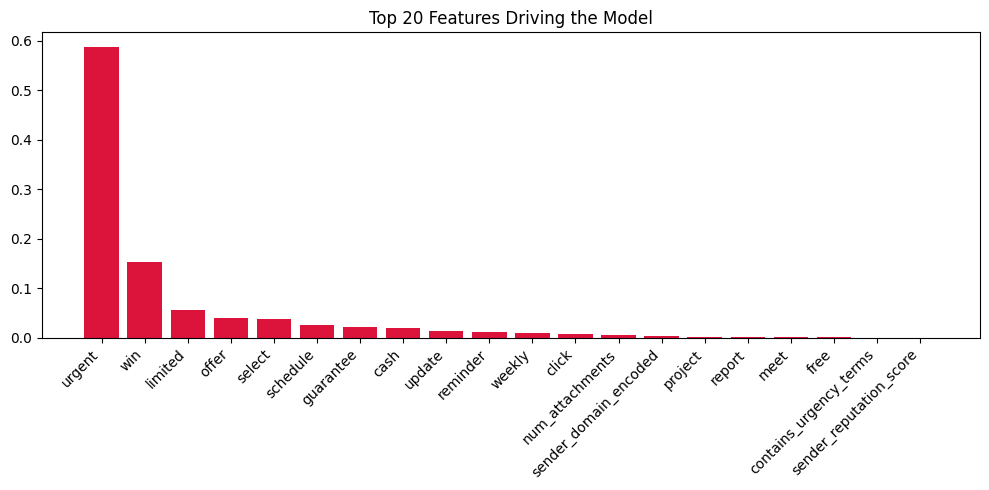

In [22]:
# ========================================================
# 1. Feature Importance Analysis
# ========================================================
import matplotlib.pyplot as plt

# إعادة بناء أسماء الميزات بالترتيب الصحيح (النصوص + الأرقام)
text_features = list(tfidf.get_feature_names_out())
numeric_features = list(X_num_train.columns)
all_features = text_features + numeric_features

# استخراج قيم الأهمية من نموذج XGBoost المدرب سابقاً
importances = xgb_model.feature_importances_

# ترتيب الميزات من الأكثر أهمية للأقل
indices = np.argsort(importances)[::-1]

print("--- Top 15 Most Predictive Features ---")
for i in range(15):
    print(f"{i+1}. {all_features[indices[i]]}: {importances[indices[i]]:.4f}")

# رسم بياني لأعلى 20 ميزة مؤثرة
plt.figure(figsize=(10, 5))
plt.title("Top 20 Features Driving the Model")
plt.bar(range(20), importances[indices[:20]], color='crimson', align="center")
plt.xticks(range(20), [all_features[i] for i in indices[:20]], rotation=45, ha='right')
plt.tight_layout()
plt.savefig("top_features.png")
plt.show()

In [23]:
# ========================================================
# 2. Stress Test: Decoupled Evaluation
# ========================================================
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# الاختبار الأول: موديل يعتمد على النصوص فقط (Text-Only)
print("\n=== Testing TEXT-ONLY Model ===")
svm_text = LinearSVC(random_state=42, max_iter=2000)
svm_text.fit(X_text_train_tfidf, y_train)
text_preds = svm_text.predict(X_text_test_tfidf)
print(classification_report(y_test, text_preds))

# الاختبار الثاني: موديل يعتمد على البيانات الرقمية فقط (Metadata-Only)
print("\n=== Testing METADATA-ONLY Model ===")
svm_meta = LinearSVC(random_state=42, max_iter=2000)
svm_meta.fit(X_num_train_scaled, y_train)
meta_preds = svm_meta.predict(X_num_test_scaled)
print(classification_report(y_test, meta_preds))


=== Testing TEXT-ONLY Model ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


=== Testing METADATA-ONLY Model ===
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1201
           1       0.83      0.83      0.83       799

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [24]:
import joblib

# 1. حفظ نماذج التعلم الآلي التقليدية
joblib.dump(svm_model, 'spam_svm_model.joblib')
joblib.dump(xgb_model, 'spam_xgb_model.joblib')

# 2. حفظ أدوات المعالجة والتشفير (الضرورية جداً لإعادة تشغيل الكود)
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le, 'label_encoder.joblib')

# 3. حفظ نموذج الشبكة العصبية العميقة (TensorFlow H5)
hybrid_model.save('spam_hybrid_attention_model.h5')

print("تم حفظ النماذج الثلاثة وأدوات المعالجة المتطابقة مع ملفك بنجاح!")

تم حفظ النماذج الثلاثة وأدوات المعالجة المتطابقة مع ملفك بنجاح!
